# Policy Gradient Methods

## Why Policy Gradient?

Value-based methods (DQN) learn $Q(s,a)$ and derive policy indirectly. **Policy gradient** methods directly parameterize and optimize the policy $\pi_\theta(a|s)$.

**Advantages**:
- Works naturally with continuous action spaces
- Can learn stochastic policies
- Better convergence properties in some settings

**Objective**: Maximize expected return

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^T \gamma^t R_t\right] = \mathbb{E}_{\tau \sim \pi_\theta}[G_0]$$

---

## Policy Gradient Theorem

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[Q^{\pi_\theta}(s,a) \nabla_\theta \ln \pi_\theta(a|s)\right]$$

**Intuition**: Increase the log-probability of actions that led to high returns, decrease those that led to low returns.

$\nabla_\theta \ln \pi_\theta(a|s)$ is called the **score function** or **log-likelihood ratio**.

---

## REINFORCE

Monte-Carlo policy gradient use actual return $G_t$ as unbiased estimate of $Q^{\pi}(s_t,a_t)$:

$$\theta \leftarrow \theta + \alpha G_t \nabla_\theta \ln \pi_\theta(A_t|S_t)$$

**With baseline** (reduces variance, no bias change):

$$\theta \leftarrow \theta + \alpha (G_t - b(S_t)) \nabla_\theta \ln \pi_\theta(A_t|S_t)$$

Common baseline: $b(S_t) = V(S_t)$, making the update use the **advantage** $A_t = G_t - V(S_t)$.

---

## Actor-Critic (A2C)

Two networks:
- **Actor** $\pi_\theta(a|s)$: the policy (what to do)
- **Critic** $V_\phi(s)$: estimates state value (how good is this state)

**Advantage** estimate:

$$A(s_t, a_t) = R_{t+1} + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$$

**Actor loss** (maximize):

$$L_{actor} = -\mathbb{E}[A(s_t,a_t) \ln \pi_\theta(a_t|s_t)]$$

**Critic loss** (minimize):

$$L_{critic} = \mathbb{E}\left[(R_{t+1} + \gamma V_\phi(s_{t+1}) - V_\phi(s_t))^2\right]$$

**A3C** (Asynchronous A2C): multiple parallel workers updating shared network asynchronously.

---

## TRPO (Trust Region Policy Optimization)

Large policy updates can be catastrophically bad. TRPO constrains the update:

$$\max_\theta \mathbb{E}\left[\frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)} A^{\pi_{old}}(s,a)\right]$$

Subject to:

$$\mathbb{E}_s\left[D_{KL}(\pi_{old}(\cdot|s) \| \pi_\theta(\cdot|s))\right] \leq \delta$$

Requires second-order optimization (expensive).

---

## PPO (Proximal Policy Optimization)

Simpler, more efficient approximation of TRPO. Uses a **clipped surrogate objective**:

$$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)} \quad \text{(probability ratio)}$$

$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$

**Full PPO objective** (with value and entropy terms):

$$L(\theta) = L^{CLIP}(\theta) - c_1 L^{VF}(\theta) + c_2 H[\pi_\theta](s_t)$$

- $L^{VF}$: value function loss
- $H[\pi_\theta]$: entropy bonus (encourages exploration)

---

## SAC (Soft Actor-Critic)

Adds entropy maximization to the objective (maximum entropy RL):

$$J(\pi) = \sum_t \mathbb{E}_{(s_t,a_t)\sim\pi}\left[R(s_t,a_t) + \alpha H(\pi(\cdot|s_t))\right]$$

where $H(\pi(\cdot|s)) = -\mathbb{E}_{a\sim\pi}[\log\pi(a|s)]$ and $\alpha$ is the temperature (auto-tuned).

Uses two Q-networks (like Double DQN), actor, and value network. State-of-the-art for continuous control.

---

## TD3 (Twin Delayed DDPG)

Builds on DDPG (off-policy actor-critic) with three tricks:
1. **Twin critics**: take min of two Q-values to reduce overestimation
2. **Delayed actor updates**: update actor less frequently than critic
3. **Target policy smoothing**: add noise to target actions

Episode 100 | Avg Reward (last 50): 28.4


Episode 200 | Avg Reward (last 50): 45.4


Episode 300 | Avg Reward (last 50): 102.7


Episode 400 | Avg Reward (last 50): 223.2


Episode 500 | Avg Reward (last 50): 315.3


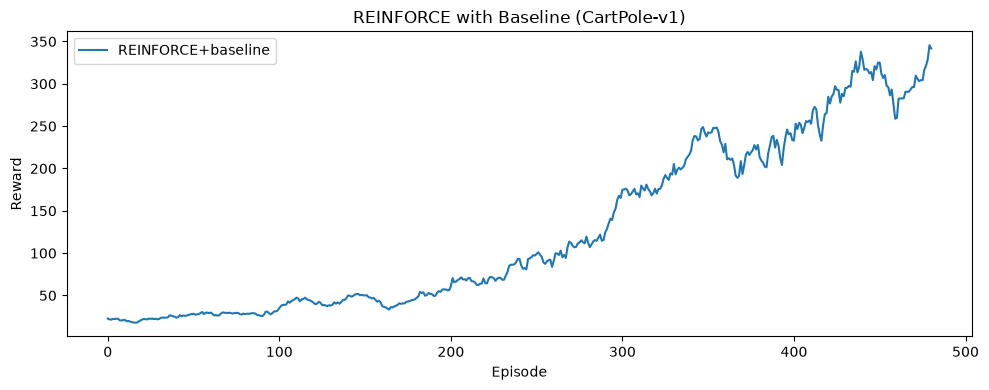

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ─── REINFORCE on CartPole ───
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)


def compute_returns(rewards, gamma=0.99):
    returns, G = [], 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    return (returns - returns.mean()) / (returns.std() + 1e-8)  # normalize


try:
    import gymnasium as gym
    env = gym.make('CartPole-v1')
    obs_dim = env.observation_space.shape[0]
    n_acts  = env.action_space.n
    device  = torch.device('cpu')

    policy  = PolicyNet(obs_dim, n_acts).to(device)
    value   = ValueNet(obs_dim).to(device)
    p_opt   = optim.Adam(policy.parameters(), lr=1e-3)
    v_opt   = optim.Adam(value.parameters(),  lr=1e-3)

    all_rewards = []
    for ep in range(500):
        obs, _ = env.reset()
        log_probs, rewards, states = [], [], []
        for _ in range(500):
            s = torch.FloatTensor(obs).to(device)
            probs = policy(s)
            dist  = torch.distributions.Categorical(probs)
            a     = dist.sample()
            log_probs.append(dist.log_prob(a))
            states.append(s)
            obs, r, terminated, truncated, _ = env.step(a.item())
            rewards.append(r)
            if terminated or truncated: break

        all_rewards.append(sum(rewards))
        returns = compute_returns(rewards).to(device)
        states_t = torch.stack(states)

        # Value update
        v_pred = value(states_t)
        v_loss = nn.MSELoss()(v_pred, returns)
        v_opt.zero_grad(); v_loss.backward(); v_opt.step()

        # Policy update with baseline
        with torch.no_grad():
            baseline = value(states_t)
        advantages = returns - baseline
        p_loss = -torch.stack(log_probs) @ advantages / len(rewards)
        p_opt.zero_grad(); p_loss.backward(); p_opt.step()

        if (ep+1) % 100 == 0:
            print(f"Episode {ep+1:3d} | Avg Reward (last 50): {np.mean(all_rewards[-50:]):.1f}")

    env.close()
    plt.figure(figsize=(10,4))
    w = 20
    plt.plot(np.convolve(all_rewards, np.ones(w)/w, mode='valid'), label='REINFORCE+baseline')
    plt.xlabel('Episode'); plt.ylabel('Reward')
    plt.title('REINFORCE with Baseline (CartPole-v1)')
    plt.legend(); plt.tight_layout(); plt.show()

except ImportError:
    print("Install: pip install gymnasium torch")

In [2]:
# ─── PPO with Stable-Baselines3 ───
try:
    from stable_baselines3 import PPO, SAC, TD3
    from stable_baselines3.common.env_util import make_vec_env
    import gymnasium as gym

    # PPO on CartPole
    env = make_vec_env('CartPole-v1', n_envs=4)
    ppo_model = PPO('MlpPolicy', env, verbose=0, n_steps=128, batch_size=64,
                    n_epochs=4, gamma=0.99, learning_rate=3e-4, clip_range=0.2)
    ppo_model.learn(total_timesteps=50_000)

    test_env = gym.make('CartPole-v1')
    obs, _ = test_env.reset()
    total_r = 0
    for _ in range(500):
        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = test_env.step(action)
        total_r += r
        if terminated or truncated: break
    print(f"PPO test reward: {total_r}")
    test_env.close()

    # SAC on continuous env (Pendulum)
    sac_env = gym.make('Pendulum-v1')
    sac_model = SAC('MlpPolicy', sac_env, verbose=0)
    sac_model.learn(total_timesteps=20_000)
    print("SAC trained on Pendulum-v1")

except ImportError:
    print("Install: pip install stable-baselines3")

PPO test reward: 500.0


SAC trained on Pendulum-v1


## Additional Learning Resources

### Papers
- **REINFORCE** Williams 1992: https://link.springer.com/article/10.1007/BF00992696
- **A3C** Asynchronous Methods for DRL: https://arxiv.org/abs/1602.01783
- **TRPO**: https://arxiv.org/abs/1502.05477
- **PPO**: https://arxiv.org/abs/1707.06347
- **SAC**: https://arxiv.org/abs/1801.01290
- **TD3**: https://arxiv.org/abs/1802.09477

### Courses
- **Hugging Face RL Course Unit 4** (Policy Gradient): https://huggingface.co/learn/deep-rl-course/unit4
- **Spinning Up** PPO & SAC explanations: https://spinningup.openai.com/en/latest/algorithms/ppo.html

### Libraries
- **Stable-Baselines3** (PPO, SAC, TD3 ready-to-use): https://stable-baselines3.readthedocs.io/
- **CleanRL** (readable single-file implementations): https://github.com/vwxyzjn/cleanrl
- **TorchRL** (PyTorch native): https://github.com/pytorch/rl